# Filters
In this activity, you will build a filter by combining current and past samples to control which frequencies of sound are kept or removed.

## What you'll learn in this module

- How digital filters shape audio by keeping or removing frequency content.
- How to implement filter structures using current and past samples in SystemVerilog.
- How to test filter behavior and connect it with the rest of the FPGA audio chain.

---

## What are Filters?

Sound is made up of many different frequencies. FFT (Fast Fourier Transform) converts the audio signals from our microphone into its frequency components so you can see frequencies make up sound, this is what is displayed on the monitor. 

Generally:
- Lower-pitched voices contain more low frequencies (left side of the FFT display)
- Higher-pitched voices contain more high frequencies (right side of the FFT display)

A filter lets us control which frequencies we keep and which we remove from a signal.

### Types of Filters
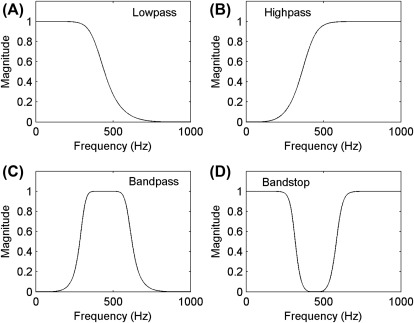

#### Some terminology:
- Passband: frequencies you want to keep
- Stopband: frequencies you want to remove
- Cutoff frequency: the boundary between passband and stopband

#### Types of filters: 
- Low-pass filter: keeps frequencies below its cutoff frequency 	
- High-pass filter: keeps frequencies above its cutoff frequency 
- Band-pass filter: keeps frequencies within a specific range (between $f_{1}$ and $f_{2}$)
- Band-stop filter: removes frequencies within a specific range, keeping everything else

---

## Building Filters

We will be building a fourth-order filter.

It’s not super important to fully understand what that means yet. You’ll cover that in more detail in the classroom. For now, you can think of the **order** of a filter as how much complexity it has, or how many past values it uses to shape the signal.

We are using a fourth-order filter because this level of complexity works well for processing audio signals.

Instead of building one large, complicated filter, we build it in **smaller pieces**.

Look at the image below:

- Each green block is a **2nd-order filter**  
- We connect them one after another which is called **cascading**  

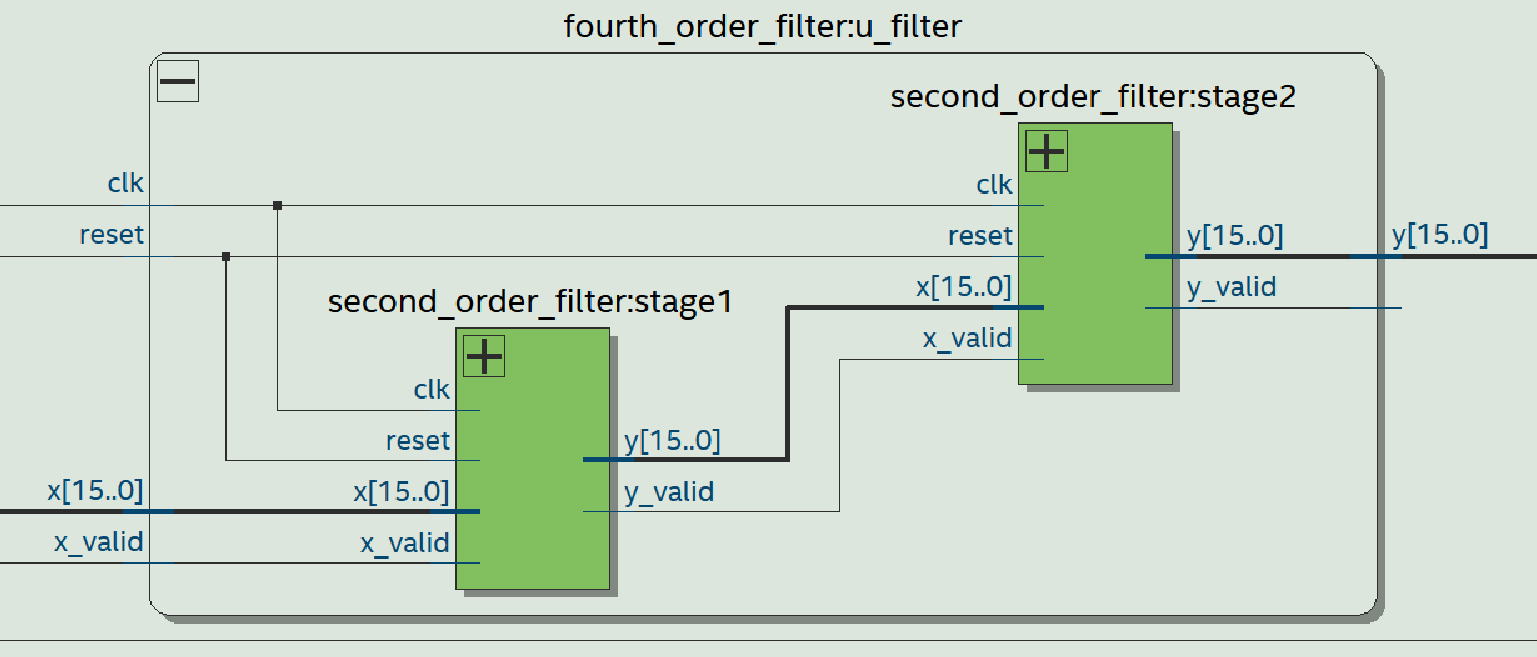

Each stage is **2nd-order**, and when we chain two of them together, we get a **4th-order filter**.

This approach is easier to design, debug, and commonly used in real systems. 

### What You Are Doing

You are only responsible for building **one of these blocks**.

- You will implement a **2nd-order filter**  
- We have already provided a module called `fourth_order_filter` that uses your block twice  
- This creates the full 4th-order filter  

So focus on getting one stage working correctly because that is all you need.

---

## How to Make a 2nd-Order Filter

The equation for the filter you're going to make is:

$$
y[n] = b_0x[n] + b_1x[n-1] + b_2x[n-2] - a_1y[n-1] - a_2y[n-2]
$$

where:
- $x[n]$ is the current input sample  
- $x[n-1]$ and $x[n-2]$ are previous input samples  
- $y[n-1]$ and $y[n-2]$ are previous output samples  
- $b_0, b_1, b_2, a_1, a_2$ are the filter coefficients  
- $y[n]$ is the current output sample  

Different sets of coefficient values create different types of filters.

These coefficient values are often calculated using tools like MATLAB.

For this workshop, we will start by giving you precomputed coefficient values so you can focus on understanding how the filter works and implementing it.

Later, you can experiment with changing the coefficients to create your own filters.

## Implementing the Filter Module

Open `second_order_filter.sv`.

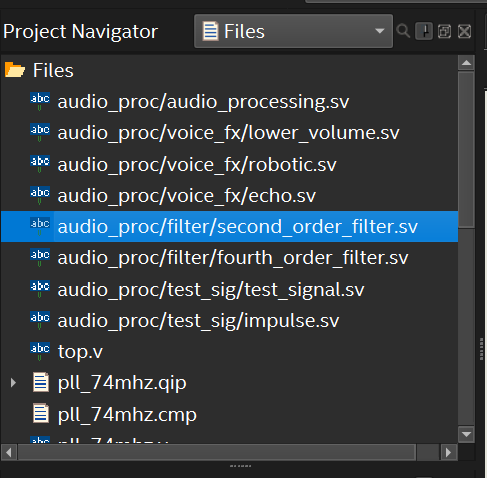

### Required signals
We have given you the needed signals for this module. 

### How the code matches the equation
Recall the filter equation:
$$
y[n] = b_0x[n] + b_1x[n-1] + b_2x[n-2] - a_1y[n-1] - a_2y[n-2]
$$

In the code:

- `x` is $x[n]$  
- `y` is $y[n]$  
- `y_raw` is the full equation **before** scaling, because all the coefficients are scaled by $2^{15}$
- `y_next` is the scaled result (after shifting) and represents the new value of $y[n]$  

**Previous samples:**
- `x1` is $x[n-1]$  
- `x2` is $x[n-2]$  
- `y1` is $y[n-1]$  
- `y2` is $y[n-2]$  

**Multiply terms (each part of the equation):**
- `b0_mult` is $b_0 \cdot x[n]$  
- `b1_mult` is $b_1 \cdot x[n-1]$  
- `b2_mult` is $b_2 \cdot x[n-2]$  
- `a1_mult` is $a_1 \cdot y[n-1]$  
- `a2_mult` is $a_2 \cdot y[n-2]$  

### Starter Skeleton
If you are new to SystemVerilog syntax, you can use the reference sheet here: [SystemVerilog Reference Sheet](reference_sheet.ipynb)

You can use this skeleton to help you: 

```systemverilog
module second_order_filter #(
    parameter int WIDTH = 16,

    // coefficients scaled by 2^15
    parameter logic signed [19:0] B0 = 20'sd0,
    parameter logic signed [19:0] B1 = 20'sd0,
    parameter logic signed [19:0] B2 = 20'sd0,
    parameter logic signed [19:0] A1 = 20'sd0,
    parameter logic signed [19:0] A2 = 20'sd0
) (
    input logic clk,
    input logic reset,
    input logic x_valid,
    input logic signed [WIDTH-1:0] x,
    output logic signed [WIDTH-1:0] y,
    output logic y_valid
);

  // ------------------------------------------------------------------
  // Internal signals and registers
  // ------------------------------------------------------------------

  localparam int COEF_W = 20;
  localparam int PROD_W = WIDTH + COEF_W;
  localparam int ACC_W = PROD_W + 3;

  // previous samples
  logic signed [WIDTH-1:0] x1, x2;
  logic signed [WIDTH-1:0] y1, y2;

  // multiply terms
  logic signed [PROD_W-1:0] b0_mult, b1_mult, b2_mult;
  logic signed [PROD_W-1:0] a1_mult, a2_mult;

  logic signed [ACC_W-1:0] y_raw;
  logic signed [WIDTH-1:0] y_next;

  // ------------------------------------------------------------------
  // Combinational logic
  // ------------------------------------------------------------------

  // TODO: compute multiply terms
  assign b0_mult = 0;
  assign b1_mult = 0;
  assign b2_mult = 0;

  assign a1_mult = 0;
  assign a2_mult = 0;

  // TODO: combine terms into y_raw
  // y[n] = b0*x[n] + b1*x[n-1] + b2*x[n-2] - a1*y[n-1] - a2*y[n-2]
  assign y_raw   = 0;

  // TODO: scale result
  assign y_next  = 0;

  // ------------------------------------------------------------------
  // Sequential logic
  // ------------------------------------------------------------------

  always_ff @(posedge clk or posedge reset) begin
    if (reset) begin
      y_valid <= 0;
      x1 <= 0;
      x2 <= 0;
      y1 <= 0;
      y2 <= 0;
      y <= 0;

    end else if (x_valid) begin
      // TODO: assign output
      y <= 0; // y_next

      // TODO: update input history
      x2 <= 0;
      x1 <= 0;

      // TODO: update output history
      y2 <= 0;
      y1 <= 0;

      y_valid <= 1'b1; // 1-bit wide binary value representing true (1)

    end else begin
      y_valid <= 1'b0; // 1-bit wide binary value representing false (0)
    end
  end

endmodule
```

#### Hint: 
Shift the stored values down each cycle (e.g., $x1 \rightarrow x2$, $y1 \rightarrow y2$).

### Integration

Connect the `fourth_order_filter` module inside `audio_processing` so that the processed audio is sent to the output.

>**Note**
>
>For this activity, you need to add a signal to store the processed audio and another signal to indicate when the output is valid (`y_valid`).

Replace the existing parameters with the following values:

```systemverilog
// Stage 1
.STAGE1_B0(20'sd84),
.STAGE1_B1(20'sd34),
.STAGE1_B2(20'sd84),
.STAGE1_A1(-20'sd56338),
.STAGE1_A2(20'sd24935),

// Stage 2
.STAGE2_B0(20'sd32768),
.STAGE2_B1(-20'sd37190), 
.STAGE2_B2(20'sd32768),
.STAGE2_A1(-20'sd57785),
.STAGE2_A2(20'sd29712)
```

### Testing and validation

If implemented correctly, your voice should sound muffled as the higher frequencies are filtered out. On the monitor, you should also see the frequency bars reduced (attenuated).

---

## Challenge

### 1. Turn the Effect On/Off
Inside `audio_processing`, add logic so you can turn the filter on and off using one of the switches on the board.

### 2. Combine with the robotic voice 

Try combining your filter with the robotic voice effect to dampen the constant tone.

Use the following coefficients in your `fourth_order_filter` module for a band-stop filter (100–250 Hz):

```systemverilog
// Stage 1
.STAGE1_B0(20'sd28484),
.STAGE1_B1(-20'sd57329),
.STAGE1_B2(20'sd28860),
.STAGE1_A1(-20'sd64335),
.STAGE1_A2(20'sd31621),

// Stage 2
.STAGE2_B0(20'sd32768),
.STAGE2_B1(-20'sd65092),
.STAGE2_B2(20'sd32341),
.STAGE2_A1(-20'sd65282),
.STAGE2_A2(20'sd32516)
```

---

## Next Step: Create your own filters

Try designing your own filters to change how the audio sounds.

For example:
- Make the voice sound “telephone-like” with a bandpass (300-3400 Hz)
- Experiment with different cutoff frequencies

**Important Note:**

To create your own filters, you will need to generate filter coefficients using MATLAB.

Continue to the next section to generate coefficients.

---

<div style="display:flex; justify-content:space-between;">
  <span><b>Back: </b> <a href="echo.ipynb">Echo Sound Effect</a></span>
  <span><b>Next: </b> <a href="matlab_filter.ipynb">MATLAB for Filter Coefficients</a></span>
</div>